In [1]:
import pandas as pd

file = "QoL.xlsx"
xls = pd.ExcelFile(file)

dfs = []
for s in xls.sheet_names:
    temp = pd.read_excel(file, sheet_name=s)
    temp['Year'] = int(s)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

df.head()

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Year
0,1,Switzerland,208.5,178.7,74.3,68.9,123.1,8.6,28.7,23.0,70.5,2016
1,2,Denmark,206.5,142.1,74.3,81.9,84.9,5.9,25.6,29.9,70.6,2016
2,3,New Zealand,201.1,115.5,63.6,72.6,78.2,6.3,31.1,19.0,88.4,2016
3,4,Germany,199.7,147.6,67.0,75.8,65.5,7.1,29.1,29.9,63.0,2016
4,5,Australia,198.8,147.3,56.9,73.7,78.5,8.4,34.7,22.9,77.3,2016


In [2]:
df[df.isnull().any(axis=1)]

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Year
123,Showing 1 to 67 of 67 entries,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017


In [3]:
df = df.dropna()
df = df.drop(columns=['Rank'])

In [4]:
num_cols = df.select_dtypes(include=['number']).columns
df = df[(df[num_cols] >= 0).all(axis=1)]

df

,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Year
0,Switzerland,208.5,178.7,74.3,68.9,123.1,8.6,28.7,23.0,70.5,2016
1,Denmark,206.5,142.1,74.3,81.9,84.9,5.9,25.6,29.9,70.6,2016
2,New Zealand,201.1,115.5,63.6,72.6,78.2,6.3,31.1,19.0,88.4,2016
3,Germany,199.7,147.6,67.0,75.8,65.5,7.1,29.1,29.9,63.0,2016
4,Australia,198.8,147.3,56.9,73.7,78.5,8.4,34.7,22.9,77.3,2016
...,...,...,...,...,...,...,...,...,...,...,...
757,Egypt,85.3,21.4,52.7,47.3,19.0,18.2,48.0,82.7,92.0,2025
758,Sri Lanka,81.1,18.5,57.9,71.4,33.5,34.2,54.5,57.9,59.1,2025
759,Venezuela,79.7,16.0,19.3,38.7,35.9,15.1,32.8,75.1,99.9,2025
760,Bangladesh,73.9,35.9,38.4,42.2,20.9,12.8,57.1,85.4,71.3,2025


In [5]:
bad_cols = [
    'Pollution Index',
    'Property Price to Income Ratio',
    'Cost of Living Index',
    'Traffic Commute Time Index'
]

for col in bad_cols:
    df[col] = df[col].max() - df[col]

Certain variables such as pollution, cost of living, and traffic commute time have a negative relationship with quality of life. To ensure consistency across all features, these variables were transformed by reversing their scale so that higher values uniformly indicate better conditions.

# Checking dataset structure

In [6]:
df.shape
df.columns
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 752 entries, 0 to 761
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Country                         752 non-null    object 
 1   Quality of Life Index           752 non-null    float64
 2   Purchasing Power Index          752 non-null    float64
 3   Safety Index                    752 non-null    float64
 4   Health Care Index               752 non-null    float64
 5   Cost of Living Index            752 non-null    float64
 6   Property Price to Income Ratio  752 non-null    float64
 7   Traffic Commute Time Index      752 non-null    float64
 8   Pollution Index                 752 non-null    float64
 9   Climate Index                   752 non-null    float64
 10  Year                            752 non-null    int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 70.5+ KB


# Target variable analysis

In [7]:
df['Quality of Life Index'].describe()

count    752.000000
mean     138.408245
std       35.447678
min        0.000000
25%      109.750000
50%      139.100000
75%      167.125000
max      220.100000
Name: Quality of Life Index, dtype: float64

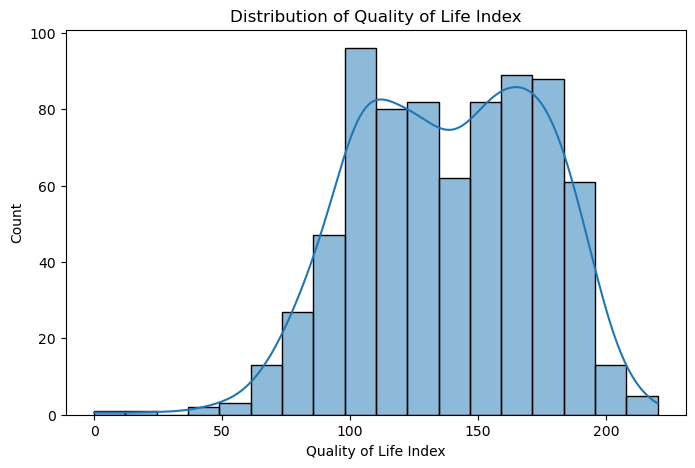

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Quality of Life Index'], kde=True)
plt.title("Distribution of Quality of Life Index")
plt.show()

In [9]:
df['Quality of Life Index'].skew()

np.float64(-0.22048090314720145)

The distribution of the Quality of Life Index is slightly negatively skewed, indicating a mild concentration of observations toward higher values. However, the skewness is close to zero, suggesting that the distribution is approximately symmetric.
The distribution of the Quality of Life Index is slightly negatively skewed, indicating a mild concentration of observations toward higher values. However, the skewness is close to zero, suggesting that the distribution is approximately symmetric.

## EDA

# Check feature–target relationships

In [10]:
corr = df.corr(numeric_only=True)['Quality of Life Index'].sort_values(ascending=False)
print(corr)

Quality of Life Index             1.000000
Pollution Index                   0.862541
Purchasing Power Index            0.831403
Traffic Commute Time Index        0.679572
Health Care Index                 0.594530
Safety Index                      0.546608
Property Price to Income Ratio    0.523705
Climate Index                     0.047330
Year                             -0.078166
Cost of Living Index             -0.678997
Name: Quality of Life Index, dtype: float64


The correlation analysis reveals that the most influential factors affecting the Quality of Life Index are Pollution and Purchasing Power. After adjusting the direction of variables, both show a strong positive relationship with quality of life, indicating that lower pollution and higher income levels significantly improve living standards.

Additionally, variables such as traffic conditions, housing affordability, healthcare, and safety exhibit moderate positive correlations, suggesting their supportive role in determining quality of life. 

The Cost of Living Index shows a negative relationship, implying that higher living costs may reduce overall well-being.

Climate effect appears negligible.
Time effect is also negligible. This shows that Quality of life varies more across countries than over time, so location matters more than year.

# Non-Linearity Check

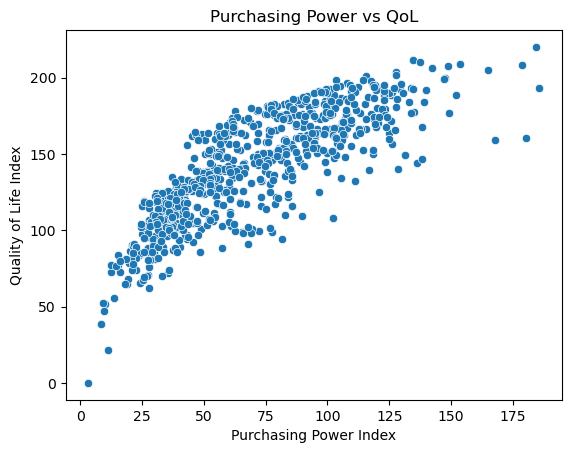

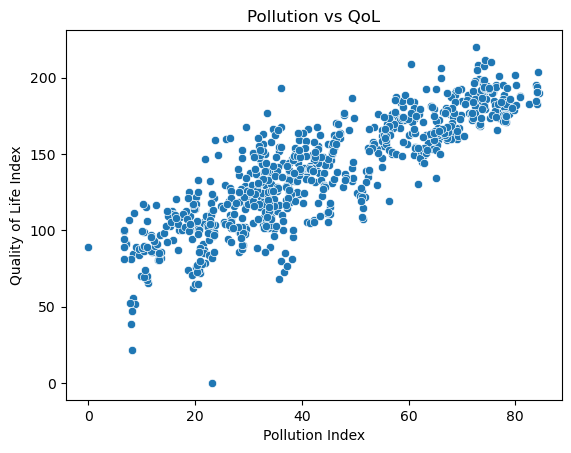

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Purchasing Power vs QoL
sns.scatterplot(x=df['Purchasing Power Index'], y=df['Quality of Life Index'])
plt.title("Purchasing Power vs QoL")
plt.show()

# Pollution vs QoL
sns.scatterplot(x=df['Pollution Index'], y=df['Quality of Life Index'])
plt.title("Pollution vs QoL")
plt.show()

The scatter plots reveal that the relationships between the Quality of Life Index and key predictors such as Purchasing Power and Pollution are not strictly linear. While both variables show strong positive associations with quality of life, the patterns exhibit curvature and increasing dispersion at higher values. In particular, purchasing power demonstrates diminishing marginal effects, where increases in income lead to smaller improvements in quality of life at higher levels. Similarly, the effect of environmental quality varies across countries, indicating heterogeneous impacts. These findings suggest the presence of nonlinear relationships, supporting the use of machine learning models such as XGBoost and LSTM over traditional linear models

In [12]:
import statsmodels.api as sm

X = df['Purchasing Power Index']
y = df['Quality of Life Index']

X = sm.add_constant(X)  
model = sm.OLS(y, X).fit()

print(model.summary())



                              OLS Regression Results                             
Dep. Variable:     Quality of Life Index   R-squared:                       0.691
Model:                               OLS   Adj. R-squared:                  0.691
Method:                    Least Squares   F-statistic:                     1679.
Date:                   Fri, 17 Apr 2026   Prob (F-statistic):          1.43e-193
Time:                           23:53:48   Log-Likelihood:                -3307.9
No. Observations:                    752   AIC:                             6620.
Df Residuals:                        750   BIC:                             6629.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [13]:
df['PP_squared'] = df['Purchasing Power Index'] ** 2

X_poly = df[['Purchasing Power Index', 'PP_squared']]
X_poly = sm.add_constant(X_poly)

model_poly = sm.OLS(y, X_poly).fit()
print(model_poly.summary())

                              OLS Regression Results                             
Dep. Variable:     Quality of Life Index   R-squared:                       0.745
Model:                               OLS   Adj. R-squared:                  0.744
Method:                    Least Squares   F-statistic:                     1095.
Date:                   Fri, 17 Apr 2026   Prob (F-statistic):          5.05e-223
Time:                           23:53:48   Log-Likelihood:                -3235.8
No. Observations:                    752   AIC:                             6478.
Df Residuals:                        749   BIC:                             6491.
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

Preliminary linear regression analysis reveals that the relationship between Purchasing Power and Quality of Life is non-linear, exhibiting diminishing returns. This is further supported by improved model fit under log and polynomial transformations.
These findings justify the use of flexible non-linear models such as XGBoost, which can capture complex relationships without requiring explicit functional form specification.

In [14]:
X = df['Pollution Index']
y = df['Quality of Life Index']

X = sm.add_constant(X)  
model = sm.OLS(y, X).fit()

print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     Quality of Life Index   R-squared:                       0.744
Model:                               OLS   Adj. R-squared:                  0.744
Method:                    Least Squares   F-statistic:                     2179.
Date:                   Fri, 17 Apr 2026   Prob (F-statistic):          4.29e-224
Time:                           23:53:48   Log-Likelihood:                -3237.4
No. Observations:                    752   AIC:                             6479.
Df Residuals:                        750   BIC:                             6488.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const       

In [15]:
df['PP_squared'] = df['Pollution Index'] ** 2

X_poly = df[['Pollution Index', 'PP_squared']]
X_poly = sm.add_constant(X_poly)

model_poly = sm.OLS(y, X_poly).fit()
print(model_poly.summary())

                              OLS Regression Results                             
Dep. Variable:     Quality of Life Index   R-squared:                       0.746
Model:                               OLS   Adj. R-squared:                  0.745
Method:                    Least Squares   F-statistic:                     1098.
Date:                   Fri, 17 Apr 2026   Prob (F-statistic):          1.90e-223
Time:                           23:53:48   Log-Likelihood:                -3234.8
No. Observations:                    752   AIC:                             6476.
Df Residuals:                        749   BIC:                             6490.
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const       

# Multicollinearity

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num = df.select_dtypes(include='number').drop(columns=['Quality of Life Index'])

import pandas as pd

vif = pd.DataFrame()
vif["Feature"] = X_num.columns
vif["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
print(vif)

                          Feature         VIF
0          Purchasing Power Index   13.603332
1                    Safety Index   35.875803
2               Health Care Index   76.466962
3            Cost of Living Index   42.750991
4  Property Price to Income Ratio  484.187857
5      Traffic Commute Time Index   29.195636
6                 Pollution Index  137.364161
7                   Climate Index   23.133102
8                            Year  609.177593
9                      PP_squared   59.805872


The Variance Inflation Factor (VIF) analysis indicates the presence of strong multicollinearity among the explanatory variables. Most variables exhibit VIF values significantly above the conventional threshold of 10, suggesting that they are highly correlated and may represent overlapping dimensions of economic and social development. In particular, the extremely high VIF value for the year variable reflects a strong temporal trend shared across indicators. While such multicollinearity poses challenges for traditional linear regression models, it does not adversely affect tree-based methods such as XGBoost or deep learning models like LSTM, which are capable of handling complex and correlated feature spaces.

## Table 1. Descriptive statistics of quality of life indices for the period 2016–2025

In [17]:
countries_2025 = df[df['Year'] == 2025]['Country'].unique()
df_filtered = df[df['Country'].isin(countries_2025)]

df_avg = df_filtered.groupby('Country').mean(numeric_only=True).reset_index()

num_df = df_avg.drop(columns=['Country'])

table1 = num_df.describe().T

table1.rename(columns={
    'count': 'N',
    'mean': 'Mean',
    'std': 'Std Dev',
    'min': 'Min',
    'max': 'Max'
}, inplace=True)

table1 = table1.reset_index()
table1.rename(columns={'index': 'Variable'}, inplace=True)

# FINAL OUTPUT
print(table1[['Variable', 'N', 'Mean', 'Std Dev', 'Min', 'Max']])

                          Variable     N         Mean      Std Dev  \
0            Quality of Life Index  88.0   135.496225    35.318485   
1           Purchasing Power Index  88.0    65.099978    32.113442   
2                     Safety Index  88.0    59.727223    13.729024   
3                Health Care Index  88.0    64.152645    10.090927   
4             Cost of Living Index  88.0    81.103739    19.125118   
5   Property Price to Income Ratio  88.0   188.678160     7.431442   
6       Traffic Commute Time Index  88.0    29.304550     8.263084   
7                  Pollution Index  88.0    42.246775    20.690806   
8                    Climate Index  88.0    76.069188    16.945969   
9                             Year  88.0  2021.230335     1.068698   
10                      PP_squared  88.0  2213.194136  1899.669237   

            Min          Max  
0     44.533333   198.475000  
1     10.250000   139.775000  
2     17.320000    85.633333  
3     38.580000    85.162500  
4   

# Pre Processing

In [18]:
df_model = df.copy()

bad_cols = [
    "Pollution Index",
    "Property Price to Income Ratio",
    "Cost of Living Index",
    "Traffic Commute Time Index"
]

for col in bad_cols:
    df_model[col] = df_model[col].max() - df_model[col]


from sklearn.model_selection import GroupShuffleSplit

features = [
    "Purchasing Power Index",
    "Safety Index",
    "Health Care Index",
    "Cost of Living Index",
    "Property Price to Income Ratio",
    "Traffic Commute Time Index",
    "Pollution Index",
    "Climate Index"
]

X = df_model[features]
y = df_model["Quality of Life Index"]
groups = df_model["Country"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=2
)

for train_idx, test_idx in gss.split(X, y, groups):
    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

# XGBOOST MODEL

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=50,
    learning_rate=0.085,
    max_depth=2,
    min_child_weight=12,
    gamma=2.8,
    subsample=0.78,
    colsample_bytree=0.48,
    reg_alpha=2.0,
    reg_lambda=6.5,
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)

print("XGBoost model trained successfully.")


from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = xgb.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred)/y_test))*100

print("R²   :", round(r2,4))
print("MAE  :", round(mae,2))
print("RMSE :", round(rmse,2))
print("MAPE :", round(mape,2))

XGBoost model trained successfully.
R²   : 0.9086
MAE  : 7.65
RMSE : 10.04
MAPE : 6.28


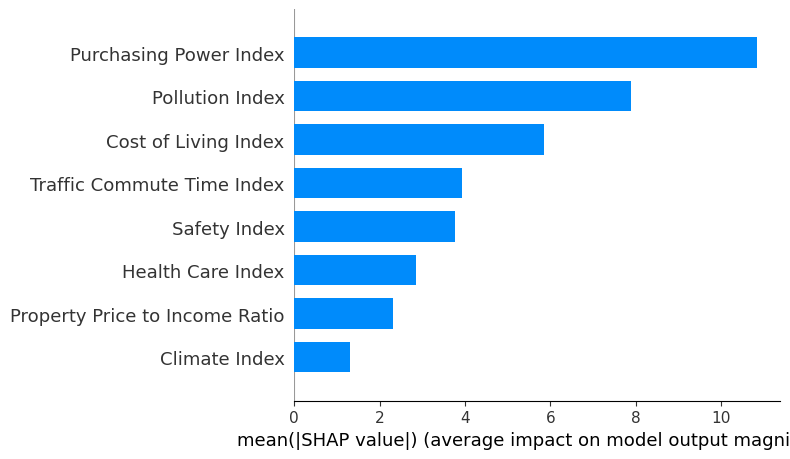

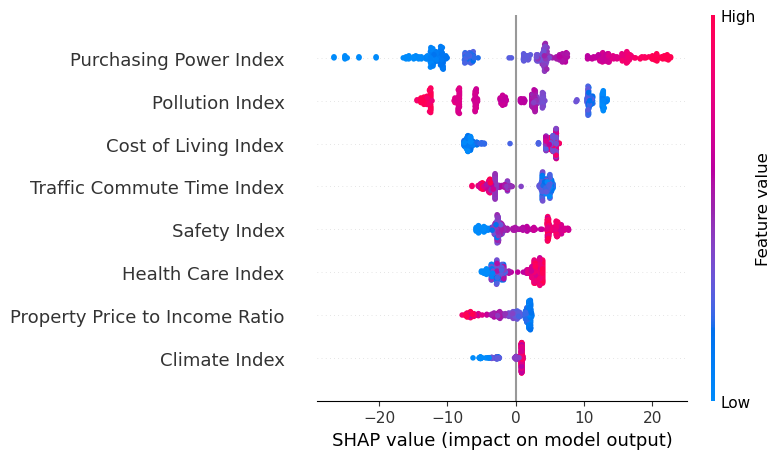

                          Feature  MeanAbsSHAP    Percent
0          Purchasing Power Index    10.841660  27.991100
6                 Pollution Index     7.885164  20.357990
3            Cost of Living Index     5.852269  15.109445
5      Traffic Commute Time Index     3.925186  10.134084
1                    Safety Index     3.765934   9.722923
2               Health Care Index     2.862504   7.390439
4  Property Price to Income Ratio     2.303193   5.946404
7                   Climate Index     1.296615   3.347612


In [19]:
import shap
import pandas as pd

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

shap.summary_plot(shap_values, X_test)

importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "MeanAbsSHAP": importance
}).sort_values("MeanAbsSHAP", ascending=False)

shap_df["Percent"] = 100 * shap_df["MeanAbsSHAP"] / shap_df["MeanAbsSHAP"].sum()

print(shap_df)

SHAP analysis identified Purchasing Power Index and Pollution Index as the two most influential predictors of the Quality of Life Index, consistent with the original study. The remaining variables had smaller contributions, with Cost of Living and Safety showing moderate importance.

In [20]:
#LSTM

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df_lstm = df.copy()

bad_cols = [
    "Pollution Index",
    "Property Price to Income Ratio",
    "Cost of Living Index",
    "Traffic Commute Time Index"
]

for col in bad_cols:
    df_lstm[col] = df_lstm[col].max() - df_lstm[col]

features = [
    "Purchasing Power Index",
    "Safety Index",
    "Health Care Index",
    "Cost of Living Index",
    "Property Price to Income Ratio",
    "Traffic Commute Time Index",
    "Pollution Index",
    "Climate Index"
]

target = "Quality of Life Index"

df_lstm = df_lstm.sort_values(["Country", "Year"]).reset_index(drop=True)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

df_lstm[features] = scaler_x.fit_transform(df_lstm[features])
df_lstm[[target]] = scaler_y.fit_transform(df_lstm[[target]])


seq_len = 3

X_seq = []
y_seq = []

for country in df_lstm["Country"].unique():
    temp = df_lstm[df_lstm["Country"] == country].reset_index(drop=True)

    if len(temp) > seq_len:
        for i in range(len(temp) - seq_len):
            X_seq.append(temp.loc[i:i+seq_len-1, features].values)
            y_seq.append(temp.loc[i+seq_len, target])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

X shape: (486, 3, 8)
y shape: (486,)


In [21]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


np.random.seed(42)
tf.random.set_seed(42)



df_lstm = df.copy()

bad_cols = [
    "Pollution Index",
    "Property Price to Income Ratio",
    "Cost of Living Index",
    "Traffic Commute Time Index"
]

for col in bad_cols:
    df_lstm[col] = df_lstm[col].max() - df_lstm[col]

features = [
    "Purchasing Power Index",
    "Safety Index",
    "Health Care Index",
    "Cost of Living Index",
    "Property Price to Income Ratio",
    "Traffic Commute Time Index",
    "Pollution Index",
    "Climate Index"
]

target = "Quality of Life Index"

df_lstm = df_lstm.sort_values(["Country", "Year"]).reset_index(drop=True)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

df_lstm[features] = scaler_x.fit_transform(df_lstm[features])
df_lstm[[target]] = scaler_y.fit_transform(df_lstm[[target]])



seq_len = 3
X_seq, y_seq = [], []

for country in df_lstm["Country"].unique():
    temp = df_lstm[df_lstm["Country"] == country].reset_index(drop=True)

    if len(temp) > seq_len:
        for i in range(len(temp) - seq_len):
            X_seq.append(temp.loc[i:i+seq_len-1, features].values)
            y_seq.append(temp.loc[i+seq_len, target])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)


X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.20,
    random_state=42,
    shuffle=False
)


model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(3,8)),
    Dropout(0.15),

    LSTM(64),
    Dropout(0.15),

    Dense(32, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)


history = model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=500,
    batch_size=8,
    verbose=1,
    callbacks=[early_stop]
)


y_pred = model.predict(X_test)

y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_inv = scaler_y.inverse_transform(y_pred).flatten()


r2 = r2_score(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape = np.mean(np.abs((y_test_inv - y_pred_inv)/y_test_inv))*100

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

C:\Users\johri\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0803 - val_loss: 0.0062
Epoch 2/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0085 - val_loss: 0.0047
Epoch 3/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0061 - val_loss: 0.0025
Epoch 4/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0059 - val_loss: 0.0025
Epoch 5/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0051 - val_loss: 0.0022
Epoch 6/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0042 - val_loss: 0.0019
Epoch 7/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038 - val_loss: 0.0017
Epoch 8/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045 - val_loss: 0.0015
Epoch 9/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 10/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0037 - val_loss: 0.0013
Epoch 11/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0029 - val_loss: 0.0013
Epoch 12/500
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


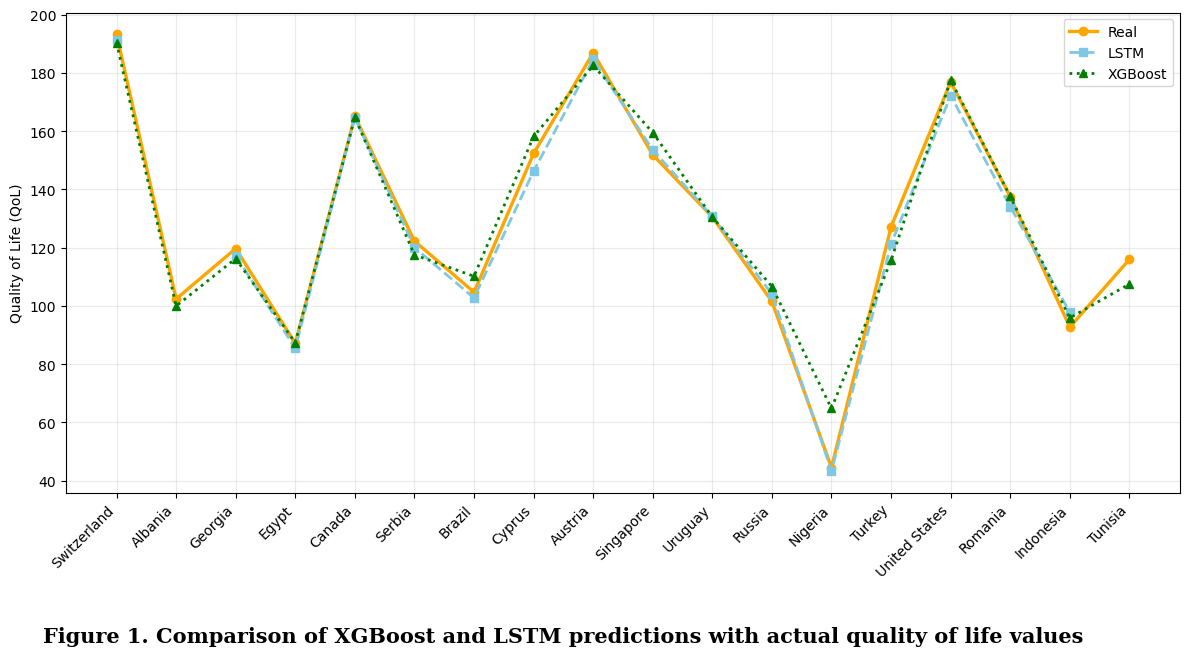

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Predict ALL LSTM sequences

all_pred = model.predict(X_seq)
all_pred_inv = scaler_y.inverse_transform(all_pred).flatten()


# XGBoost predictions 

df_plot = df.copy()
df_plot["xgb_pred"] = xgb.predict(df_model[features])


# Build LSTM prediction rows

rows = []
counter = 0

for country in df_lstm["Country"].unique():
    temp = df_lstm[df_lstm["Country"] == country].copy().reset_index(drop=True)

    if len(temp) > 3:
        usable = len(temp) - 3

        for j in range(usable):
            rows.append({
                "Country": temp.loc[j+3, "Country"],
                "Year": temp.loc[j+3, "Year"],
                "lstm_pred": all_pred_inv[counter]
            })
            counter += 1

lstm_pred_df = pd.DataFrame(rows)

#  Merge

df_plot = df_plot.merge(
    lstm_pred_df,
    on=["Country", "Year"],
    how="left"
)

# Average by country

avg = df_plot.groupby("Country").agg({
    "Quality of Life Index":"mean",
    "xgb_pred":"mean",
    "lstm_pred":"mean"
}).reset_index()



countries = [
    "Switzerland","Albania","Georgia","Egypt","Canada","Serbia",
    "Brazil","Cyprus","Austria","Singapore","Uruguay","Russia",
    "Nigeria","Turkey","United States","Romania","Indonesia","Tunisia"
]

avg = avg[avg["Country"].isin(countries)].copy()
avg["Country"] = pd.Categorical(avg["Country"], countries)
avg = avg.sort_values("Country")


# Plot

plt.figure(figsize=(12,6))

plt.plot(avg["Country"], avg["Quality of Life Index"],
         color="orange", marker="o", linewidth=2.4, label="Real")

plt.plot(avg["Country"], avg["lstm_pred"],
         color="#7ec8e3", linestyle="--", marker="s", linewidth=2, label="LSTM")

plt.plot(avg["Country"], avg["xgb_pred"],
         color="green", linestyle=":", marker="^", linewidth=2, label="XGBoost")

plt.ylabel("Quality of Life (QoL)")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.figtext(
    0.04, -0.08,
    "Figure 1. Comparison of XGBoost and LSTM predictions with actual quality of life values",
    ha="left", fontsize=15, fontweight="bold", family="serif"
)

plt.show()

In [23]:
# GRU MODEL 

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)


df_gru = df.copy()  

bad_cols = [
    "Pollution Index",
    "Property Price to Income Ratio",
    "Cost of Living Index",
    "Traffic Commute Time Index"
]

for col in bad_cols:
    df_gru[col] = df_gru[col].max() - df_gru[col]

features = [
    "Purchasing Power Index",
    "Safety Index",
    "Health Care Index",
    "Cost of Living Index",
    "Property Price to Income Ratio",
    "Traffic Commute Time Index",
    "Pollution Index",
    "Climate Index"
]

target = "Quality of Life Index"

df_gru = df_gru.sort_values(["Country", "Year"]).reset_index(drop=True)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

df_gru[features] = scaler_x.fit_transform(df_gru[features])
df_gru[[target]] = scaler_y.fit_transform(df_gru[[target]])


seq_len = 3
X_seq, y_seq = [], []

for country in df_gru["Country"].unique():
    temp = df_gru[df_gru["Country"] == country].reset_index(drop=True)

    if len(temp) > seq_len:
        for i in range(len(temp) - seq_len):
            X_seq.append(temp.loc[i:i+seq_len-1, features].values)
            y_seq.append(temp.loc[i+seq_len, target])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence data shape:", X_seq.shape, y_seq.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)


gru_model = tf.keras.Sequential([
    tf.keras.layers.GRU(128, return_sequences=True, input_shape=(seq_len, len(features))),
    Dropout(0.15),

    tf.keras.layers.GRU(64), 
    Dropout(0.15),

    Dense(32, activation="relu"),
    Dense(1)
])

optimizer = Adam(learning_rate=0.001)

gru_model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True
)


history_gru = gru_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=500,  
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


y_pred_gru = gru_model.predict(X_test)


y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_gru_inv = scaler_y.inverse_transform(y_pred_gru).flatten()

r2_gru   = r2_score(y_test_inv, y_pred_gru_inv)
mae_gru  = mean_absolute_error(y_test_inv, y_pred_gru_inv)
rmse_gru = np.sqrt(mean_squared_error(y_test_inv, y_pred_gru_inv))
mape_gru = np.mean(np.abs((y_test_inv - y_pred_gru_inv) / y_test_inv)) * 100

print("\n=== GRU RESULTS ===")
print("R²   :", round(r2_gru, 4))
print("MAE  :", round(mae_gru, 2))
print("RMSE :", round(rmse_gru, 2))
print("MAPE :", round(mape_gru, 2))


Sequence data shape: (486, 3, 8) (486,)


C:\Users\johri\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 0.0975 - mae: 0.2361 - val_loss: 0.0229 - val_mae: 0.1278
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0143 - mae: 0.0938 - val_loss: 0.0043 - val_mae: 0.0562
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0090 - mae: 0.0745 - val_loss: 0.0030 - val_mae: 0.0459
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0079 - mae: 0.0729 - val_loss: 0.0025 - val_mae: 0.0395
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0074 - mae: 0.0696 - val_loss: 0.0029 - val_mae: 0.0447
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0066 - mae: 0.0644 - val_loss: 0.0020 - val_mae: 0.0344
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0061 - mae: 0.0621 - val_loss: 0.0015 - val_mae: 0.0291
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0060 - mae: 0.0579 - val_loss: 0.0022 - val_mae: 0.0367
Epoch 9/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss